In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Sleep_Efficiency.csv')

In [3]:
df.columns

Index(['ID', 'Age', 'Gender', 'Bedtime', 'Wakeup time', 'Sleep duration',
       'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage',
       'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
       'Alcohol consumption', 'Smoking status', 'Exercise frequency'],
      dtype='object')

In [4]:
df.shape

(452, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    object 
 3   Bedtime                 452 non-null    object 
 4   Wakeup time             452 non-null    object 
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    object 
 14  Exercise frequency      446 non-null    fl

In [6]:
df.describe()

,ID,Age,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Exercise frequency
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,446.000000
mean,226.500000,40.285398,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,1.791480
std,130.625419,13.172250,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,1.428134
min,1.000000,9.000000,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,113.750000,29.000000,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,0.000000
50%,226.500000,40.000000,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,2.000000
75%,339.250000,52.000000,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,3.000000
max,452.000000,69.000000,10.000000,0.990000,30.000000,75.000000,63.000000,4.000000,200.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

,0
ID,0
Age,0
Gender,0
Bedtime,0
Wakeup time,0
Sleep duration,0
Sleep efficiency,0
REM sleep percentage,0
Deep sleep percentage,0
Light sleep percentage,0


In [8]:
# Handling Missing Values

df['Awakenings'] = df['Awakenings'].fillna(df['Awakenings'].median())
df['Caffeine consumption'] = df['Caffeine consumption'].fillna(df['Caffeine consumption'].median())
df['Alcohol consumption'] = df['Alcohol consumption'].fillna(df['Alcohol consumption'].median())
df['Exercise frequency'] = df['Exercise frequency'].fillna(df['Exercise frequency'].median())

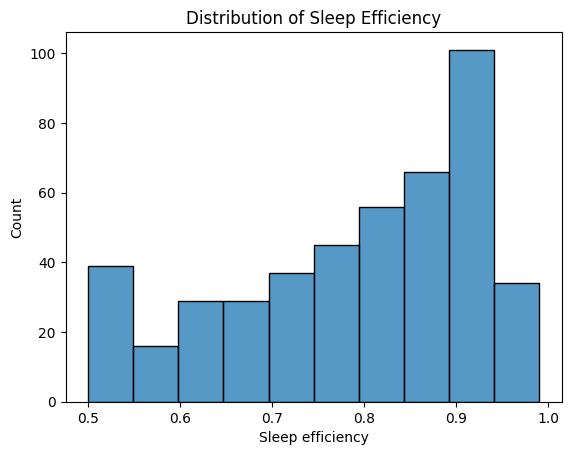

In [20]:
# 1. What is the overall distribution of Sleep Efficiency?

sns.histplot(df['Sleep efficiency'])
plt.title('Distribution of Sleep Efficiency')
plt.show()

Gender
Female    0.787545
Male      0.790263
Name: Sleep efficiency, dtype: float64


<Axes: xlabel='Gender', ylabel='Sleep efficiency'>

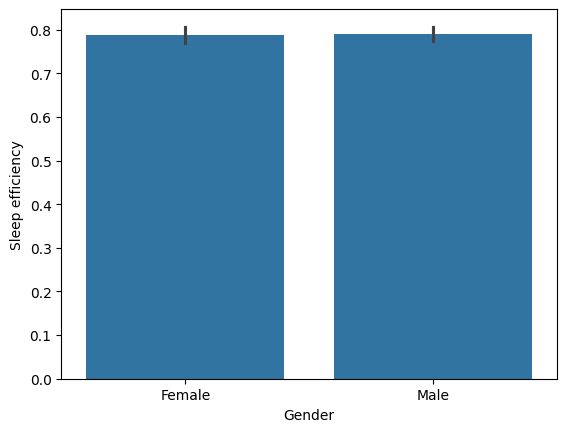

In [23]:
# 2. Which gender has higher average Sleep Efficiency?

avg_sleep = df.groupby('Gender')['Sleep efficiency'].mean()
print(avg_sleep)
sns.barplot(x='Gender',y='Sleep efficiency',data = df)

<Axes: xlabel='Age', ylabel='Sleep efficiency'>

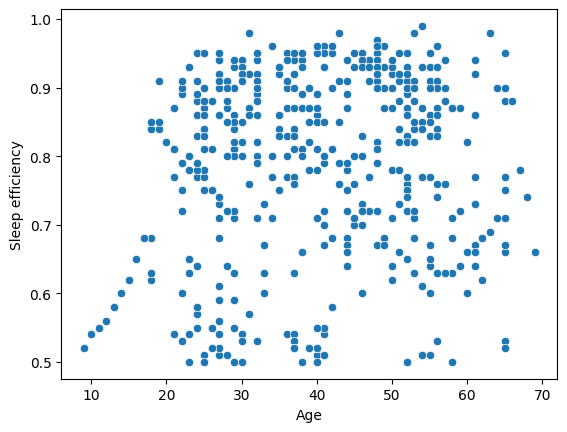

In [24]:
# 3. Does age affect Sleep Efficiency?

sns.scatterplot(x='Age',y='Sleep efficiency',data=df)

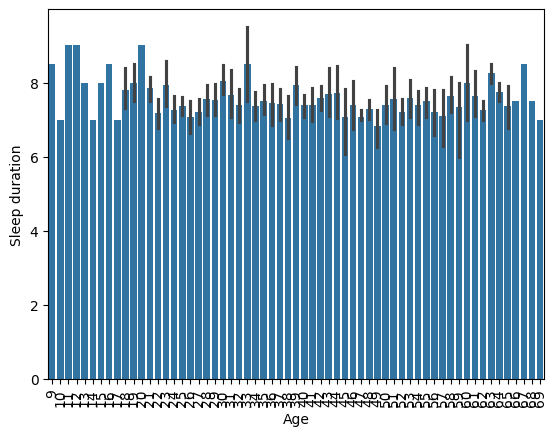

In [28]:
# 4. Which age group sleeps the longest?
sns.barplot(x='Age', y='Sleep duration', data=df)
plt.xticks(rotation=90)
plt.show()

#

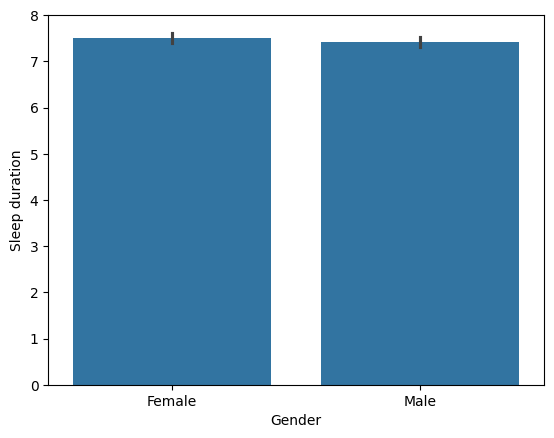

In [30]:
# 5. Compare Sleep Duration for males and females.

sns.barplot(x='Gender', y='Sleep duration', data=df)
plt.show()

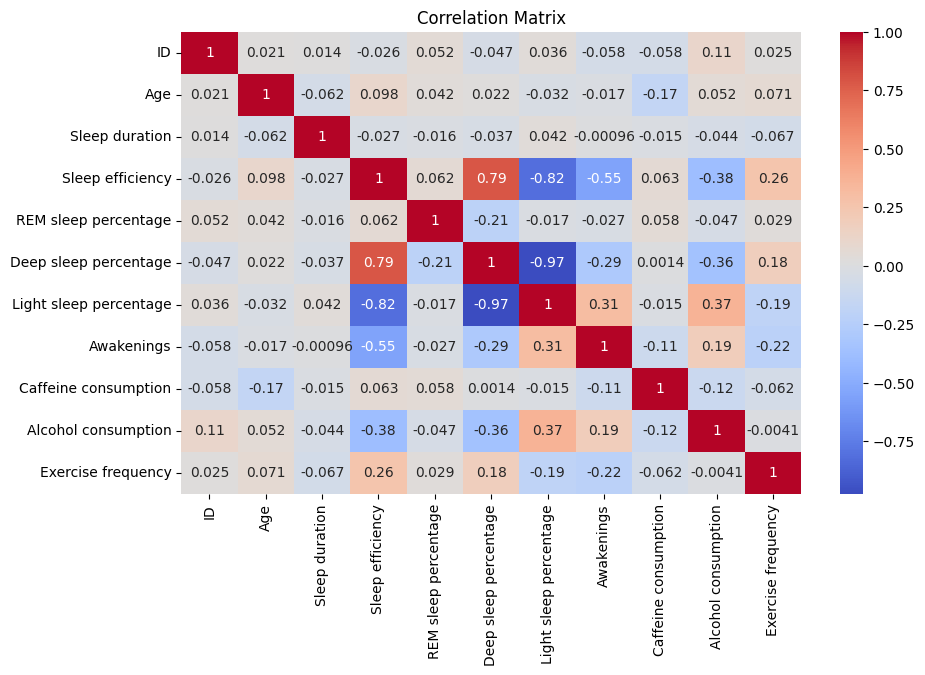

In [41]:
# 6. Which numerical features have the strongest correlation with Sleep Efficiency?
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

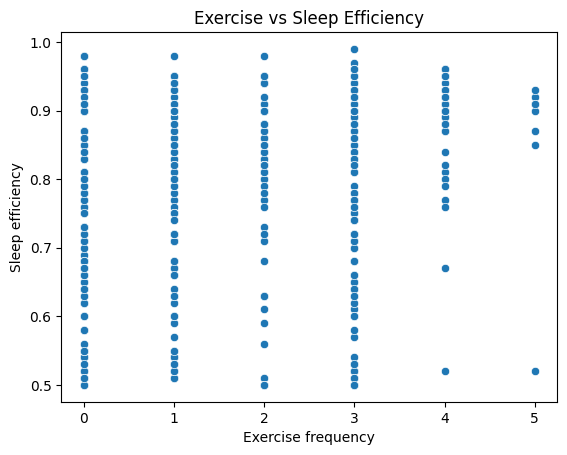

In [47]:
# 7. Do people who exercise more have better Sleep Efficiency?
sns.scatterplot(x='Exercise frequency', y='Sleep efficiency', data=df)
plt.title('Exercise vs Sleep Efficiency')
plt.show()

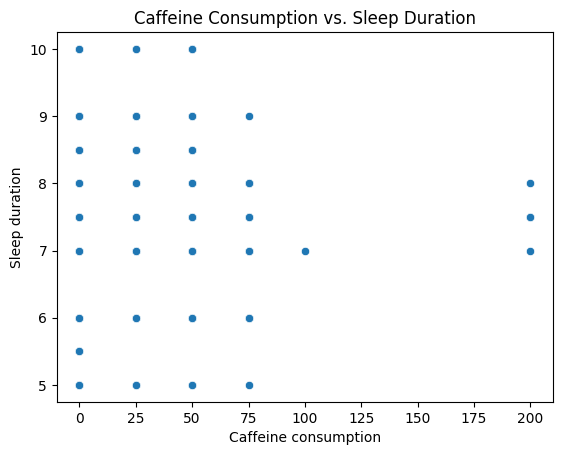

In [46]:
# 8. How does caffeine consumption affect Sleep Duration?

sns.scatterplot(x='Caffeine consumption', y='Sleep duration', data=df)
plt.title('Caffeine Consumption vs. Sleep Duration')
plt.show()

<Axes: xlabel='Alcohol consumption', ylabel='Sleep efficiency'>

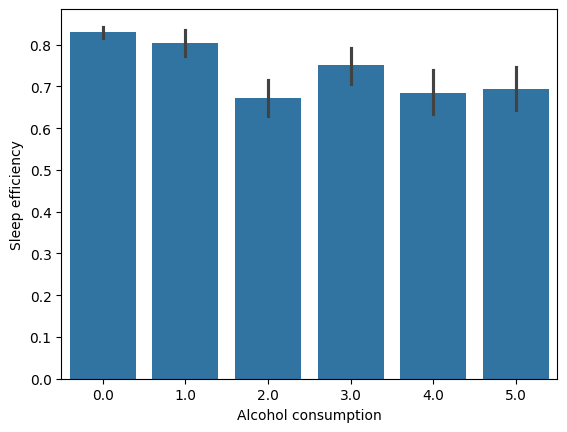

In [48]:
# 9. Does alcohol consumption reduce Sleep Efficiency?
sns.barplot(
    x='Alcohol consumption',
    y='Sleep efficiency',
    data = df
)

<Axes: xlabel='Smoking status', ylabel='Sleep efficiency'>

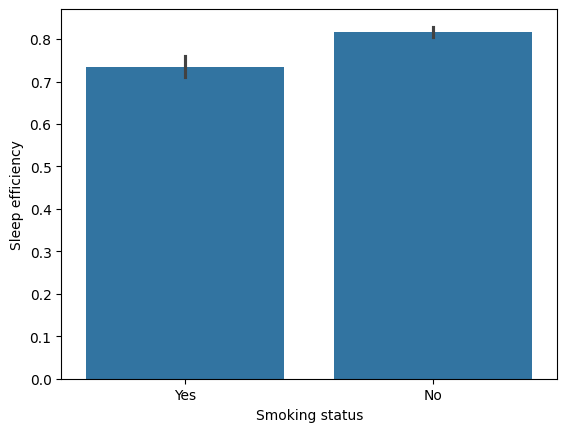

In [49]:
# 10. Compare Sleep Efficiency between smokers and non-smokers.

sns.barplot(
    data = df,
    x='Smoking status',
    y='Sleep efficiency'
)

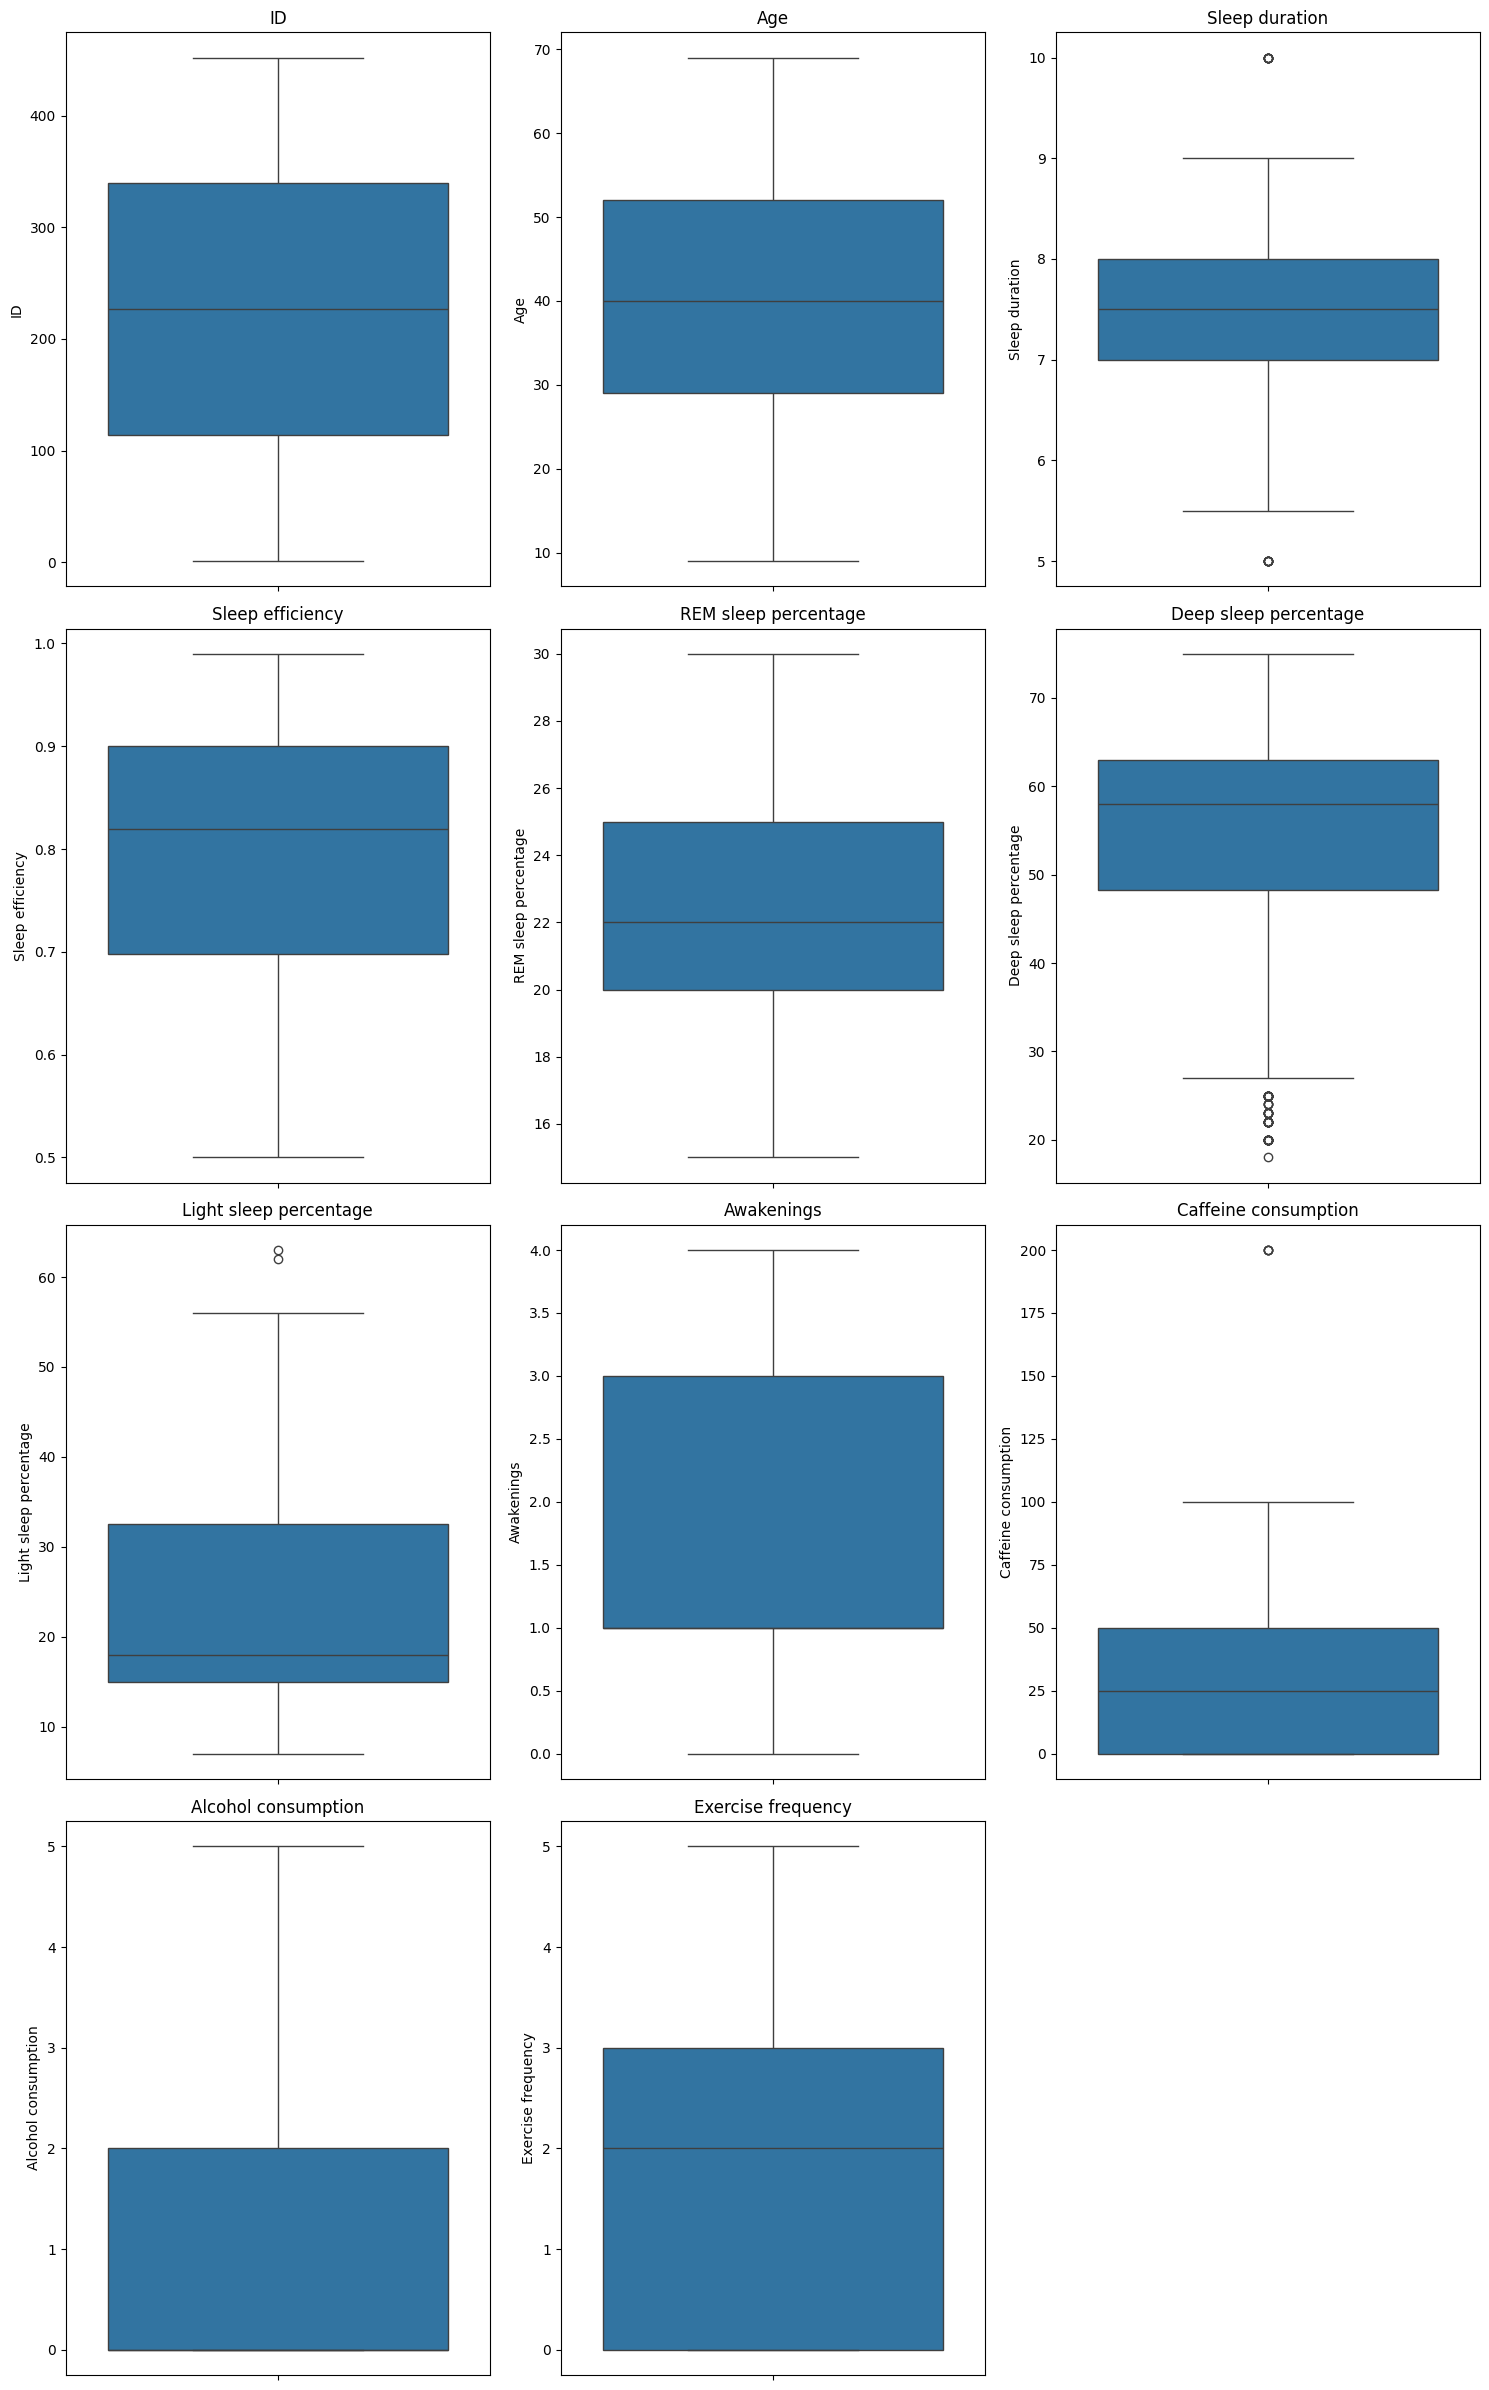

In [50]:
# 11. Which variable has the most outliers?
num_cols = df.select_dtypes(include = ['int64','Float64']).columns

rows = (len(num_cols) + 2) // 3   # 3 plots per row
plt.figure(figsize=(15, 6 * rows))

# Plot each numeric column
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='Awakenings', ylabel='Sleep efficiency'>

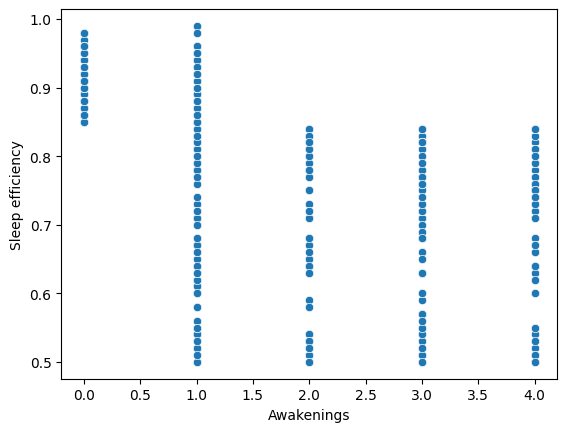

In [54]:
# 12. Is the number of awakenings related to Sleep Efficiency?
sns.scatterplot(
    x='Awakenings',
    y  = 'Sleep efficiency',
    data = df
)

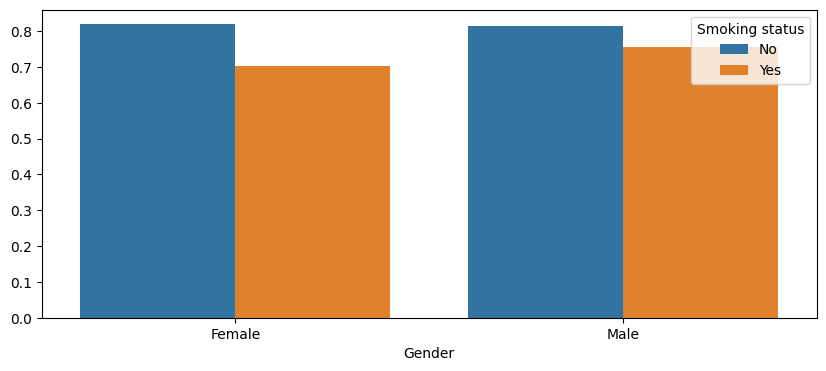

In [59]:
# 13. Which combination of Gender and Smoking Status has the highest average Sleep Efficiency?
avg_gender_smoking = df.groupby(['Gender','Smoking status'])['Sleep efficiency'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(x=avg_gender_smoking.index.get_level_values(0), y=avg_gender_smoking.values, hue=avg_gender_smoking.index.get_level_values(1))
plt.show()

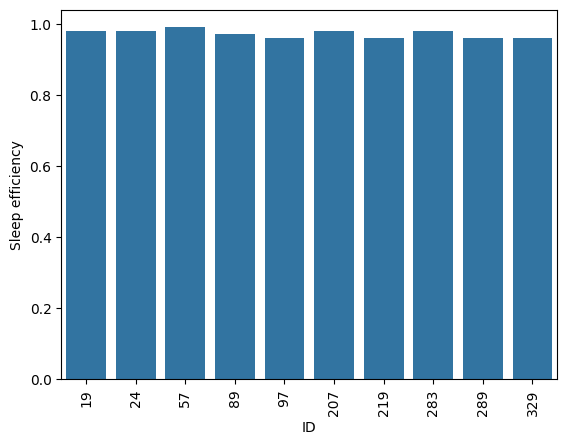

In [64]:
# 14. Which top 10 people have the highest Sleep Efficiency?
top_sleep = df.sort_values(by='Sleep efficiency', ascending=False).head(10)

sns.barplot(x='ID', y='Sleep efficiency', data=top_sleep)
plt.xticks(rotation=90)
plt.show()

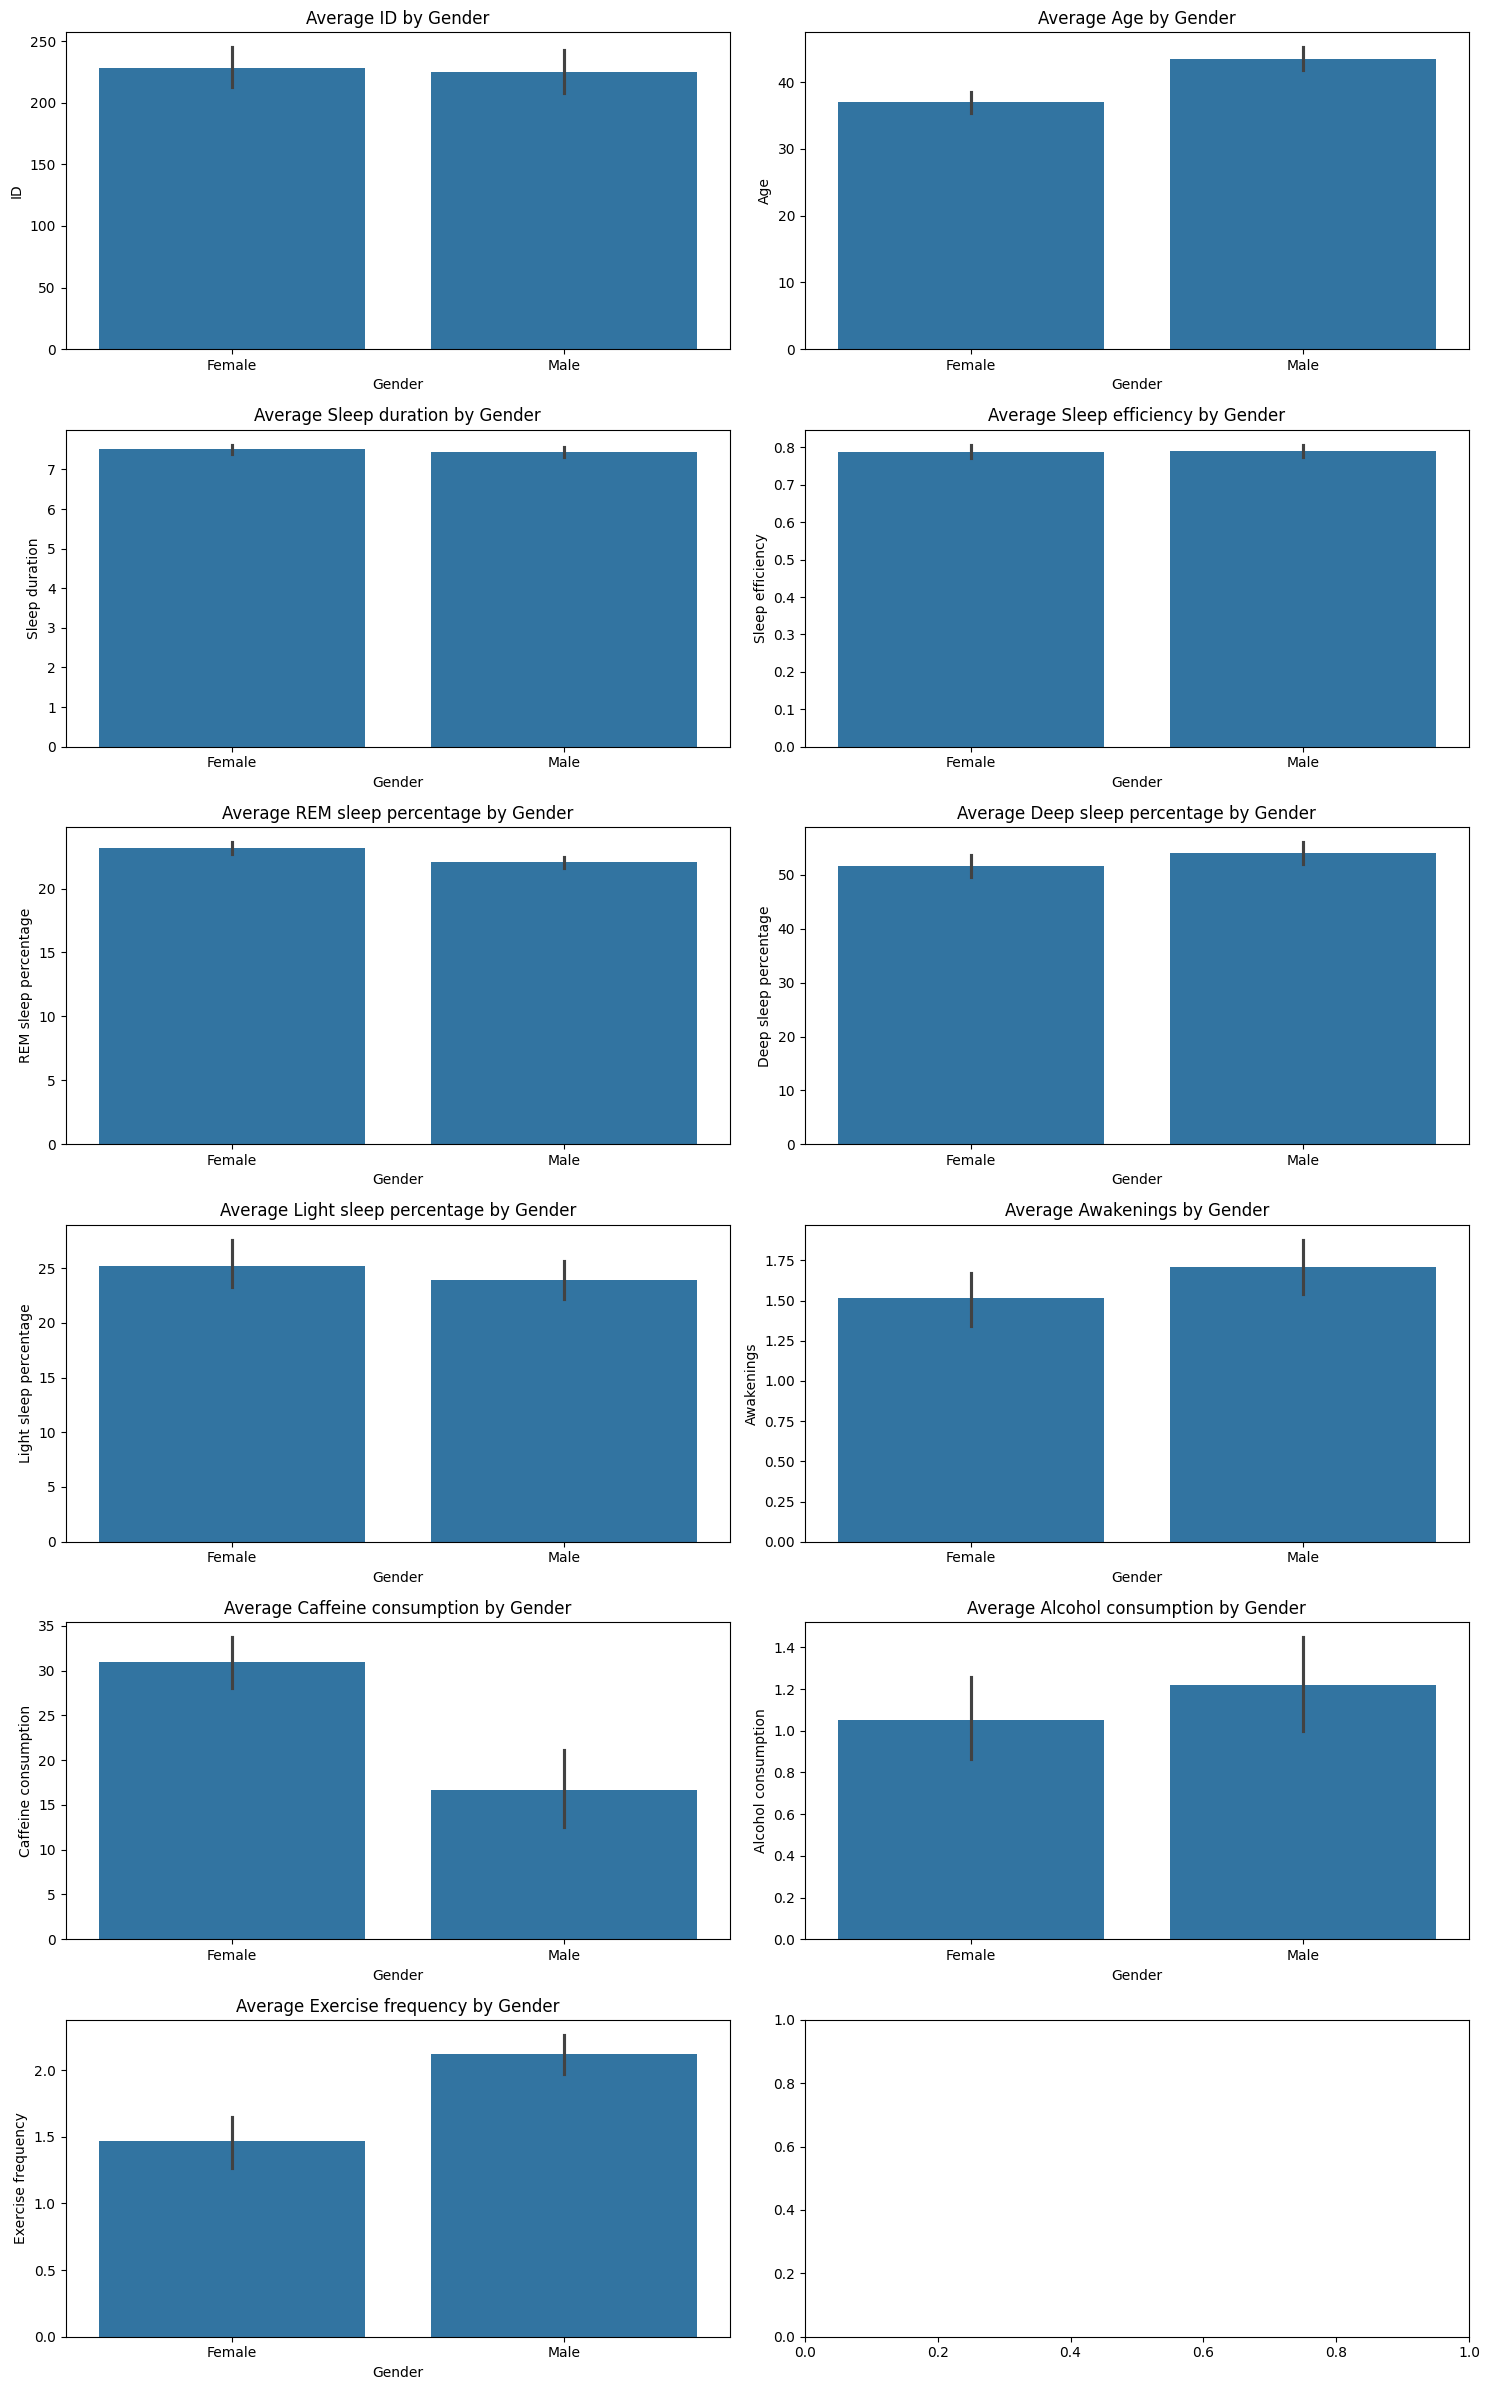

In [72]:
# 15. Create a complete sleep profile report.
# For each Gender, display:
# Number of people
# Average Age
# Average Sleep Duration
# Average Sleep Efficiency
# Average REM Sleep %
# Average Deep Sleep %
# Average Light Sleep %
# Average Awakenings
# Average Caffeine Consumption
# Average Alcohol Consumption
# Average Exercise Frequency

profile = df.groupby('Gender').agg({
    'ID': 'count',
    'Age': 'mean',
    'Sleep duration': 'mean',
    'Sleep efficiency': 'mean',
    'REM sleep percentage': 'mean',
    'Deep sleep percentage': 'mean',
    'Light sleep percentage': 'mean',
    'Awakenings': 'mean',
    'Caffeine consumption': 'mean',
    'Alcohol consumption': 'mean',
    'Exercise frequency': 'mean'
})

fig, axes = plt.subplots(6, 2, figsize=(15, 24))
axes = axes.flatten()

for i, col in enumerate(profile):
    sns.barplot(
        data=df,
        x='Gender',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f'Average {col} by Gender')

plt.tight_layout()
plt.show()